In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import MDS

from toy_disentanglement.task import create_embedding_autoencoder, LatentClassificationDataset
from toy_disentanglement.metrics import classification_generalization_accuracy, regression_generalization_r2

In [10]:
latent_dim = 5

embedding_network = create_embedding_autoencoder(
    input_dim=latent_dim,
    representation_dim=128,
    encoder_hidden_dims=[128,128],
    decoder_hidden_dims=[128,128],
    noise_std=0.0045,
    activation="relu",
    train=True,
    num_epochs=4000,
    batch_size=256,
    embedding_type="standard",
)

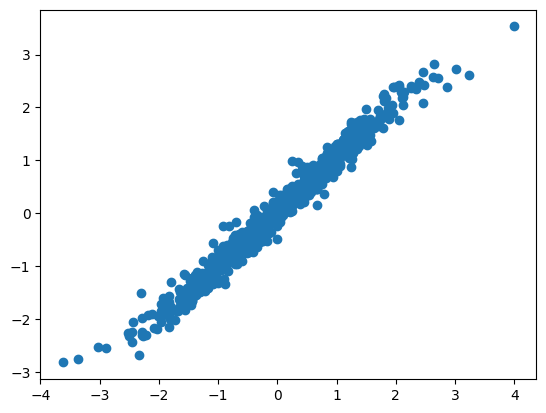

In [11]:
with torch.no_grad():
    samples = torch.randn(1000, latent_dim)
    samples_recon = embedding_network.decoder(embedding_network.encoder(samples))

plt.plot(samples[:,0].numpy(), samples_recon[:,0].numpy(), 'o')

In [139]:
# dataset = LatentClassificationDataset(num_samples=1000, latent_dim=latent_dim, num_tasks=10, embedding_fn=embedding_network.encoder)

In [10]:
classification_generalization_accuracy(
    rep_fn=torch.nn.Identity(),
    embed_fn=embedding_network.encoder,
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    task_type="random", # {"random", "axis-aligned"}
    num_tasks=10,
    split_orthogonal=True,
    bias=False,
)

(array([[0.99212598],
        [0.99183673],
        [0.99361702],
        [0.99795918],
        [0.98816568],
        [0.99217221],
        [0.99794661],
        [0.99798387],
        [0.99805825],
        [0.99375   ]]),
 array([[0.64430894],
        [0.63921569],
        [0.68490566],
        [0.6627451 ],
        [0.69574037],
        [0.62985685],
        [0.58479532],
        [0.69047619],
        [0.63298969],
        [0.67692308]]))

In [11]:
torch.save(embedding_network.state_dict(), "../data/embedding_nets/embedding_hsae_5d_relu_128x2_noiseless.pth")

In [62]:
import itertools

nonlinearities = ["relu", "tanh", "gelu"]
num_epochs = [0, 100, 1000]
widths = [128, 256]
depths = [1, 2, 4]

df = []
for nonlinearity, num_epoch, width, depth in itertools.product(nonlinearities, num_epochs, widths, depths):
    print(f"Training with nonlinearity={nonlinearity}, num_epochs={num_epoch}, width={width}, depth={depth}")
    embedding_network = create_embedding_autoencoder(
        input_dim=latent_dim,
        representation_dim=64,
        encoder_hidden_dims=[width]*depth,
        decoder_hidden_dims=[width]*depth,
        noise_std=0.0,
        activation=nonlinearity,
        train=(True if num_epoch > 0 else False),
        num_epochs=num_epoch,
        batch_size=256
    )

    train_acc, test_acc = classification_generalization_accuracy(
        rep_fn=torch.nn.Identity(),
        embed_fn=embedding_network.encoder,
        data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
        task_type="random", # {"random", "axis-aligned"}
        num_tasks=10,
        split_orthogonal=True,
        bias=False,
    )

    with torch.no_grad():
        latents = torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)).sample((1000,))
        representations = embedding_network.encoder(latents).detach().numpy()
        pca = PCA()
        pca.fit(representations)
        participation_ratio = np.square(np.sum(pca.explained_variance_)) / np.sum(np.square(pca.explained_variance_))
    
    df.append({
        "nonlinearity": nonlinearity,
        "num_epochs": num_epoch,
        "width": width,
        "depth": depth,
        "train_accuracy": train_acc.mean().item(),
        "test_accuracy": test_acc.mean().item(),
        "participation_ratio": participation_ratio,
    })

Training with nonlinearity=relu, num_epochs=0, width=128, depth=1
Training with nonlinearity=relu, num_epochs=0, width=128, depth=2
Training with nonlinearity=relu, num_epochs=0, width=128, depth=4
Training with nonlinearity=relu, num_epochs=0, width=256, depth=1
Training with nonlinearity=relu, num_epochs=0, width=256, depth=2
Training with nonlinearity=relu, num_epochs=0, width=256, depth=4
Training with nonlinearity=relu, num_epochs=100, width=128, depth=1
Training with nonlinearity=relu, num_epochs=100, width=128, depth=2
Training with nonlinearity=relu, num_epochs=100, width=128, depth=4
Training with nonlinearity=relu, num_epochs=100, width=256, depth=1
Training with nonlinearity=relu, num_epochs=100, width=256, depth=2
Training with nonlinearity=relu, num_epochs=100, width=256, depth=4
Training with nonlinearity=relu, num_epochs=1000, width=128, depth=1
Training with nonlinearity=relu, num_epochs=1000, width=128, depth=2
Training with nonlinearity=relu, num_epochs=1000, width=12

In [63]:
import pandas as pd
df = pd.DataFrame(df)
df

,nonlinearity,num_epochs,width,depth,train_accuracy,test_accuracy,participation_ratio
0,relu,0,128,1,0.996354,0.962080,3.212107
1,relu,0,128,2,0.978134,0.919478,2.871692
2,relu,0,128,4,0.904047,0.810569,3.409330
3,relu,0,256,1,0.994824,0.960929,2.985454
4,relu,0,256,2,0.988291,0.910884,3.283709
5,relu,0,256,4,0.939788,0.882552,4.230875
6,relu,100,128,1,0.989767,0.731625,8.535447
7,relu,100,128,2,0.984157,0.718451,15.146080
8,relu,100,128,4,0.884673,0.554453,22.260744
9,relu,100,256,1,0.987846,0.772694,9.538178


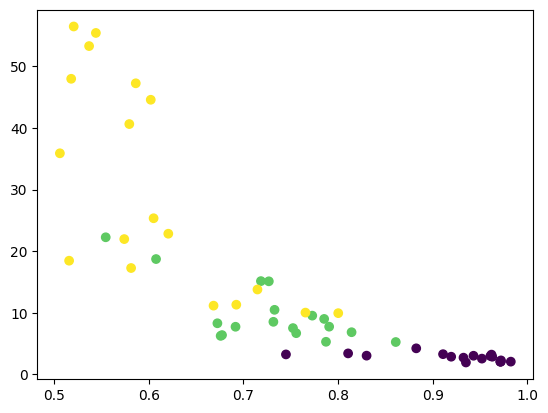

In [72]:
plt.scatter(
    df.test_accuracy, df.participation_ratio, c=np.log(df.num_epochs + 0.1)
)

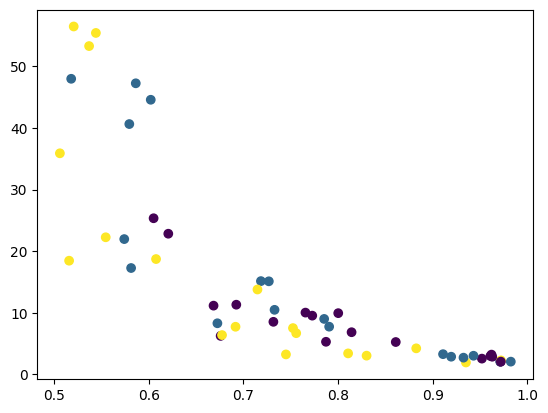

In [68]:
plt.scatter(
    df.test_accuracy, df.participation_ratio, c=df.depth, 
)

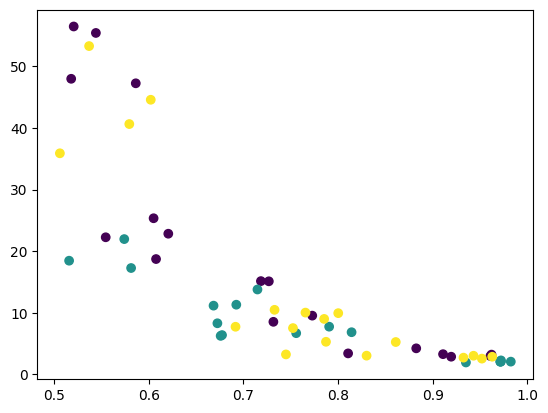

In [71]:
plt.scatter(
    df.test_accuracy, df.participation_ratio, c=df.nonlinearity.factorize()[0], 
)

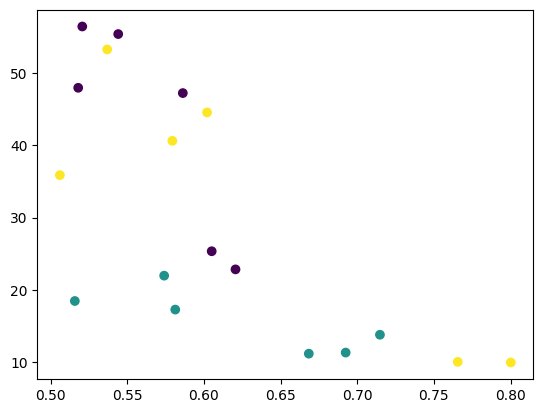

In [75]:
plt.scatter(
    df.test_accuracy[df.num_epochs == 1000], df.participation_ratio[df.num_epochs == 1000], c=df.nonlinearity.factorize()[0][df.num_epochs == 1000], 
)

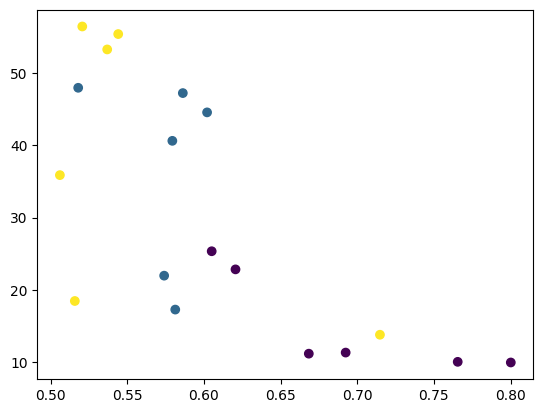

In [76]:
plt.scatter(
    df.test_accuracy[df.num_epochs == 1000], df.participation_ratio[df.num_epochs == 1000], c=df.depth[df.num_epochs == 1000], 
)

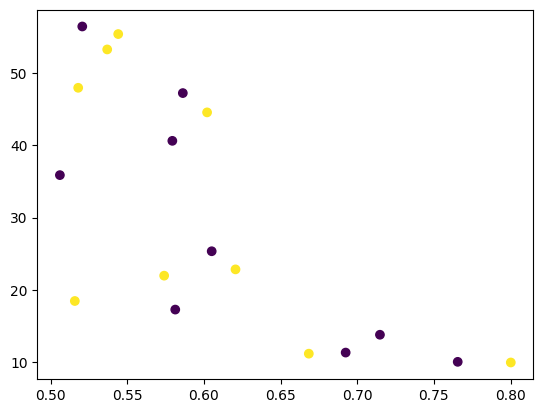

In [77]:
plt.scatter(
    df.test_accuracy[df.num_epochs == 1000], df.participation_ratio[df.num_epochs == 1000], c=df.width[df.num_epochs == 1000], 
)

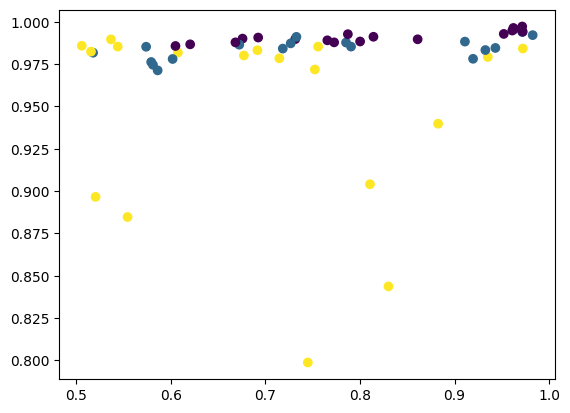

In [80]:
plt.scatter(
    df.test_accuracy, df.train_accuracy, c=df.depth, 
)